29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



ÉPOCA 1/20
Pérdida Generador: 1.0299
Pérdida Discriminador: 1.2697


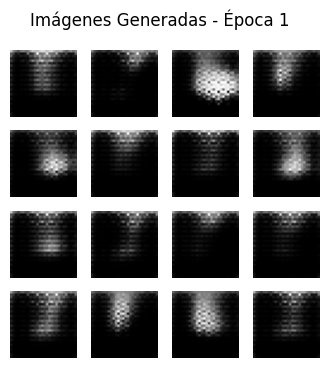

Tiempo: 742.59 segundos

ÉPOCA 2/20
Pérdida Generador: 0.9839
Pérdida Discriminador: 1.1155


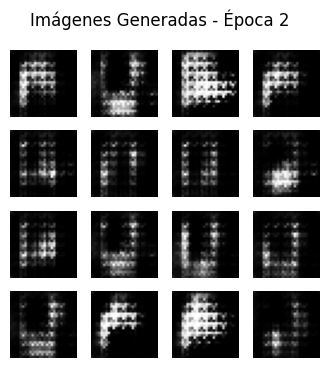

Tiempo: 742.72 segundos

ÉPOCA 3/20
Pérdida Generador: 0.8274
Pérdida Discriminador: 1.2064


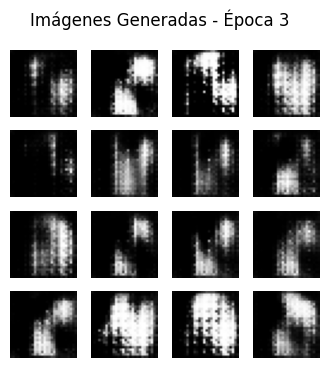

Tiempo: 728.33 segundos

ÉPOCA 4/20
Pérdida Generador: 0.8565
Pérdida Discriminador: 1.1812


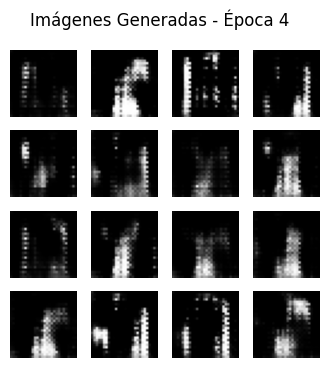

Tiempo: 742.25 segundos

ÉPOCA 5/20
Pérdida Generador: 0.9292
Pérdida Discriminador: 1.1919


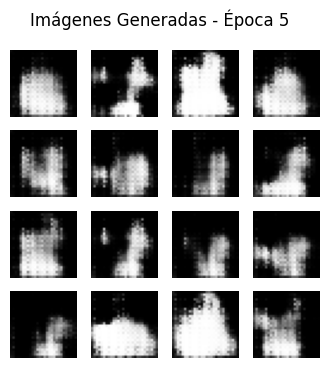

Tiempo: 742.25 segundos

ÉPOCA 6/20
Pérdida Generador: 0.7502
Pérdida Discriminador: 1.4974


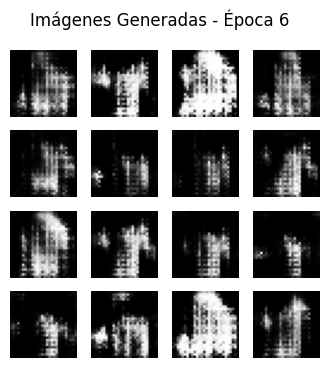

Tiempo: 720.70 segundos

ÉPOCA 7/20
Pérdida Generador: 0.7902
Pérdida Discriminador: 1.4939


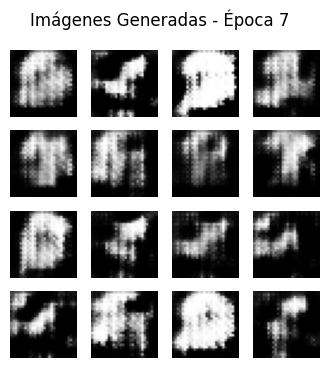

Tiempo: 722.75 segundos

ÉPOCA 8/20
Pérdida Generador: 0.8721
Pérdida Discriminador: 1.2144


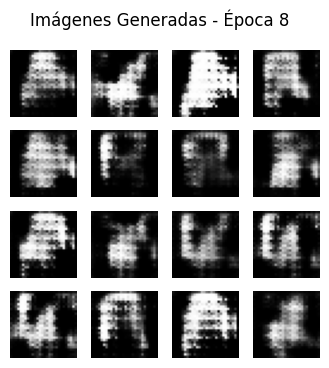

Tiempo: 721.85 segundos

ÉPOCA 9/20
Pérdida Generador: 0.7661
Pérdida Discriminador: 1.5481


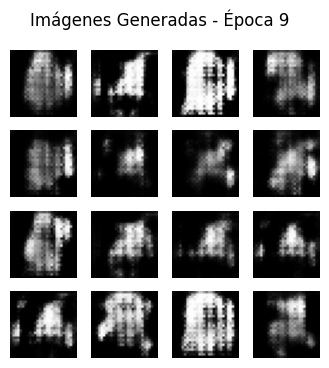

Tiempo: 720.83 segundos

ÉPOCA 10/20
Pérdida Generador: 0.8730
Pérdida Discriminador: 1.2527


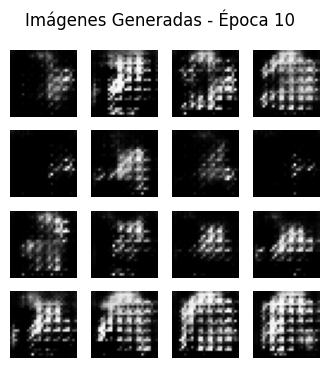

Tiempo: 721.17 segundos

ÉPOCA 11/20
Pérdida Generador: 0.7764
Pérdida Discriminador: 1.4926


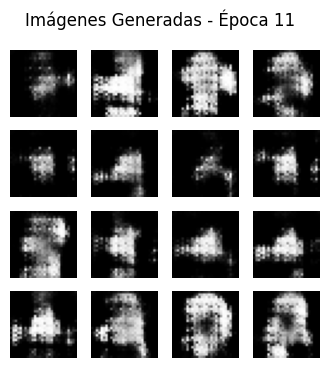

Tiempo: 742.25 segundos

ÉPOCA 12/20
Pérdida Generador: 1.1309
Pérdida Discriminador: 0.8906


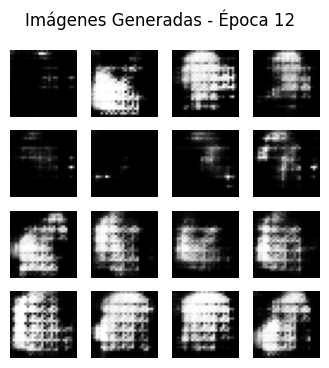

Tiempo: 742.24 segundos

ÉPOCA 13/20
Pérdida Generador: 0.9047
Pérdida Discriminador: 1.2739


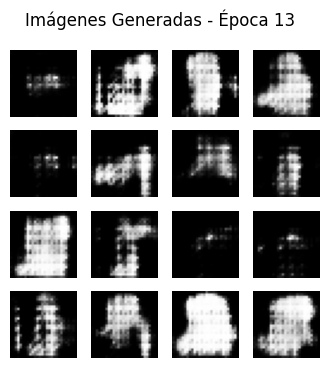

Tiempo: 720.21 segundos

ÉPOCA 14/20
Pérdida Generador: 1.0029
Pérdida Discriminador: 1.1965


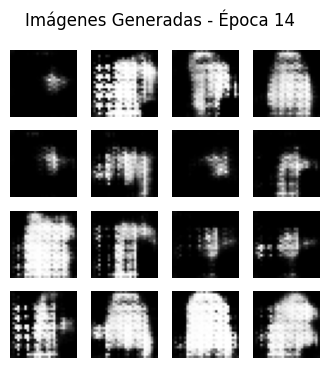

Tiempo: 718.36 segundos

ÉPOCA 15/20
Pérdida Generador: 1.2450
Pérdida Discriminador: 1.1241


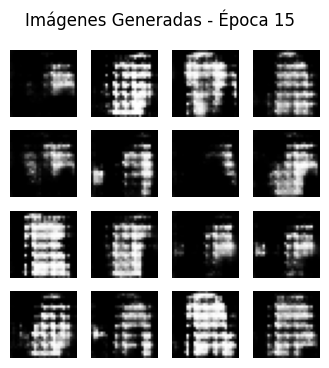

Tiempo: 719.56 segundos

ÉPOCA 16/20
Pérdida Generador: 1.1080
Pérdida Discriminador: 1.3181


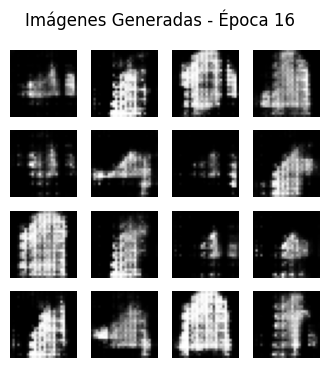

Tiempo: 742.23 segundos

ÉPOCA 17/20
Pérdida Generador: 1.5066
Pérdida Discriminador: 0.8206


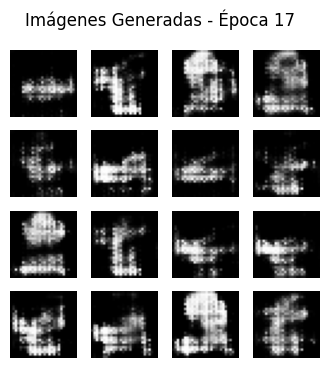

Tiempo: 719.46 segundos

ÉPOCA 18/20
Pérdida Generador: 1.2352
Pérdida Discriminador: 1.0251


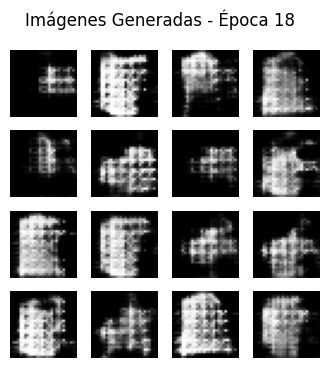

Tiempo: 742.23 segundos

ÉPOCA 19/20
Pérdida Generador: 1.2818
Pérdida Discriminador: 0.8790


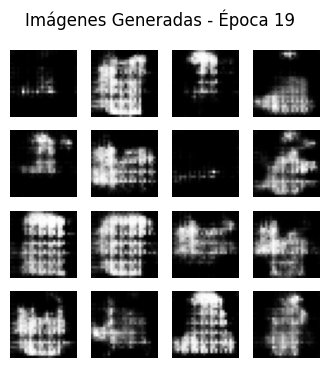

Tiempo: 721.96 segundos

ÉPOCA 20/20
Pérdida Generador: 1.0985
Pérdida Discriminador: 1.2985


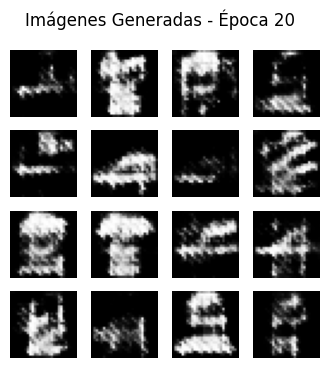

Tiempo: 721.08 segundos

GENERACIÓN FINAL


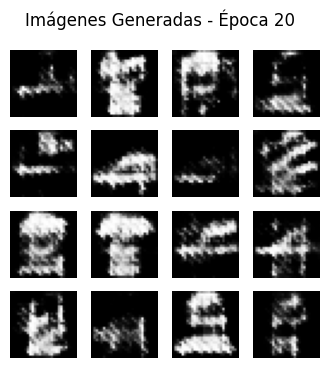

In [1]:
# ============================================================
# SEMANA 14 - ACTIVIDAD 14
# IMPLEMENTACIÓN DE UNA GAN EN GOOGLE COLAB
# ============================================================

# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# TensorFlow se utiliza para construir y entrenar la GAN
import tensorflow as tf

# Keras permite crear modelos neuronales de forma sencilla
from tensorflow.keras import layers

# NumPy se utiliza para operaciones matemáticas y manejo de arreglos
import numpy as np

# Matplotlib permite visualizar imágenes y gráficas
import matplotlib.pyplot as plt

# Librería para controlar tiempos de ejecución
import time

# ============================================================
# CONFIGURACIÓN INICIAL
# ============================================================

# Tamaño del vector de ruido aleatorio utilizado por el generador
# Este vector representa el espacio latente desde donde la GAN
# aprenderá a generar imágenes nuevas
LATENT_DIM = 100

# Tamaño del batch utilizado durante entrenamiento
BATCH_SIZE = 256

# Número de épocas de entrenamiento
EPOCHS = 20

# ============================================================
# CARGA DEL DATASET FASHION MNIST
# ============================================================

# Se carga únicamente el conjunto de entrenamiento
# ya que las GANs aprenden directamente de imágenes reales
(train_images, train_labels), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# ============================================================
# PREPROCESAMIENTO DE IMÁGENES
# ============================================================

# Conversión de enteros a float32
train_images = train_images.astype('float32')

# Normalización de píxeles:
# Originalmente las imágenes tienen valores entre 0 y 255
# Se transforman al rango [-1, 1]
train_images = (train_images - 127.5) / 127.5

# Agregar canal de profundidad
# Fashion MNIST es escala de grises
# Shape final: (28,28,1)
train_images = np.expand_dims(train_images, axis=-1)

# ============================================================
# CREACIÓN DEL DATASET PARA TENSORFLOW
# ============================================================

# Se crea un pipeline eficiente de datos
dataset = tf.data.Dataset.from_tensor_slices(train_images)

# Mezclar imágenes aleatoriamente
dataset = dataset.shuffle(buffer_size=60000)

# Crear batches
dataset = dataset.batch(BATCH_SIZE)

# ============================================================
# FUNCIÓN PARA CREAR EL GENERADOR
# ============================================================

def build_generator():
    """
    Esta función construye el modelo generador.

    El generador recibe ruido aleatorio y produce
    imágenes sintéticas similares a Fashion MNIST.
    """

    model = tf.keras.Sequential()

    # ========================================================
    # CAPA DENSE INICIAL
    # ========================================================

    # Convierte el vector aleatorio en una representación más grande
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(LATENT_DIM,)))

    # BatchNormalization estabiliza entrenamiento
    model.add(layers.BatchNormalization())

    # LeakyReLU evita problema de neuronas muertas
    model.add(layers.LeakyReLU())

    # ========================================================
    # RESHAPE
    # ========================================================

    # Convierte vector en tensor 7x7x256
    model.add(layers.Reshape((7, 7, 256)))

    # ========================================================
    # CAPA CONV2DTRANSPOSE 1
    # ========================================================

    model.add(
        layers.Conv2DTranspose(
            128,
            (5,5),
            strides=(1,1),
            padding='same',
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # ========================================================
    # CAPA CONV2DTRANSPOSE 2
    # ========================================================

    model.add(
        layers.Conv2DTranspose(
            64,
            (5,5),
            strides=(2,2),
            padding='same',
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # ========================================================
    # CAPA FINAL
    # ========================================================

    # Produce imagen 28x28x1
    model.add(
        layers.Conv2DTranspose(
            1,
            (5,5),
            strides=(2,2),
            padding='same',
            use_bias=False,
            activation='tanh'
        )
    )

    return model

# ============================================================
# FUNCIÓN PARA CREAR EL DISCRIMINADOR
# ============================================================

def build_discriminator():
    """
    Esta función construye el discriminador.

    El discriminador clasifica imágenes reales o falsas.
    """

    model = tf.keras.Sequential()

    # ========================================================
    # CAPA CONVOLUCIONAL 1
    # ========================================================

    model.add(
        layers.Conv2D(
            64,
            (5,5),
            strides=(2,2),
            padding='same',
            input_shape=[28,28,1]
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # ========================================================
    # CAPA CONVOLUCIONAL 2
    # ========================================================

    model.add(
        layers.Conv2D(
            128,
            (5,5),
            strides=(2,2),
            padding='same'
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # ========================================================
    # APLANAR Y SALIDA
    # ========================================================

    model.add(layers.Flatten())

    # Salida binaria
    model.add(layers.Dense(1))

    return model

# ============================================================
# CREACIÓN DE MODELOS
# ============================================================

generator = build_generator()
discriminator = build_discriminator()

# ============================================================
# FUNCIONES DE PÉRDIDA
# ============================================================

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    """
    Calcula pérdida del discriminador.
    """

    real_loss = cross_entropy(tf.ones_like(real_output), real_output)

    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)

    total_loss = real_loss + fake_loss

    return total_loss

def generator_loss(fake_output):
    """
    Calcula pérdida del generador.
    """

    return cross_entropy(tf.ones_like(fake_output), fake_output)

# ============================================================
# OPTIMIZADORES
# ============================================================

generator_optimizer = tf.keras.optimizers.Adam(1e-4)

discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# ============================================================
# FUNCIÓN DE ENTRENAMIENTO
# ============================================================

@tf.function
def train_step(images):
    """
    Ejecuta un paso de entrenamiento adversarial.
    """

    # ========================================================
    # GENERAR RUIDO ALEATORIO
    # ========================================================

    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    # ========================================================
    # CÁLCULO DE GRADIENTES
    # ========================================================

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generar imágenes falsas
        generated_images = generator(noise, training=True)

        # Discriminador evalúa imágenes reales
        real_output = discriminator(images, training=True)

        # Discriminador evalúa imágenes falsas
        fake_output = discriminator(generated_images, training=True)

        # Cálculo de pérdidas
        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(real_output, fake_output)

    # ========================================================
    # ACTUALIZACIÓN DE PESOS
    # ========================================================

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

# ============================================================
# FUNCIÓN PARA VISUALIZAR IMÁGENES GENERADAS
# ============================================================

def generate_and_save_images(model, epoch, test_input):
    """
    Genera imágenes durante entrenamiento.
    """

    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):

        plt.subplot(4,4,i+1)

        img = predictions[i, :, :, 0]

        img = (img * 127.5) + 127.5

        plt.imshow(img, cmap='gray')

        plt.axis('off')

    plt.suptitle(f'Imágenes Generadas - Época {epoch}')

    plt.show()

# ============================================================
# VECTOR FIJO PARA VISUALIZACIÓN
# ============================================================

seed = tf.random.normal([16, LATENT_DIM])

# ============================================================
# ENTRENAMIENTO COMPLETO
# ============================================================

def train(dataset, epochs):
    """
    Entrena la GAN completa.
    """

    for epoch in range(epochs):

        start = time.time()

        print(f"\nÉPOCA {epoch+1}/{epochs}")

        for image_batch in dataset:

            gen_loss, disc_loss = train_step(image_batch)

        print(f"Pérdida Generador: {gen_loss:.4f}")

        print(f"Pérdida Discriminador: {disc_loss:.4f}")

        generate_and_save_images(generator, epoch+1, seed)

        print(f"Tiempo: {time.time()-start:.2f} segundos")

# ============================================================
# EJECUCIÓN DEL ENTRENAMIENTO
# ============================================================

train(dataset, EPOCHS)

# ============================================================
# GENERACIÓN FINAL DE IMÁGENES
# ============================================================

print("\nGENERACIÓN FINAL")

generate_and_save_images(generator, EPOCHS, seed)

# Semana 14 – Actividad 14: Aplicación de los Conceptos de GANs en Google Colab

## Introducción

Las Redes Generativas Adversarias (GANs, Generative Adversarial Networks) representan una de las arquitecturas más importantes dentro del campo del Deep Learning y la inteligencia artificial generativa. Estas redes fueron propuestas por Ian Goodfellow en 2014 y revolucionaron la manera en que los modelos pueden aprender distribuciones complejas de datos para generar información nueva y sintética.

Una GAN está compuesta por dos redes neuronales principales que trabajan de manera adversarial:

El **Generador (Generator)** tiene como objetivo crear imágenes artificiales que sean lo suficientemente realistas como para engañar al discriminador. Para ello, recibe como entrada un vector de ruido aleatorio y lo transforma progresivamente en una imagen sintética.

El **Discriminador (Discriminator)** funciona como un clasificador binario cuya tarea es diferenciar entre imágenes reales provenientes del dataset e imágenes falsas generadas por el generador.

Durante el entrenamiento, ambas redes compiten constantemente. El generador mejora tratando de producir imágenes más convincentes, mientras que el discriminador mejora aprendiendo a detectar imágenes falsas. Este proceso competitivo permite que el generador aprenda gradualmente patrones complejos presentes en los datos reales.

El objetivo principal de esta actividad es comprender el flujo técnico completo de una GAN, incluyendo la preparación del dataset, construcción del generador y discriminador, entrenamiento adversarial y análisis de resultados obtenidos.

---

# Objetivos de la Actividad

El desarrollo de esta práctica tiene como finalidad aplicar los conceptos fundamentales relacionados con Redes Generativas Adversarias mediante un entorno práctico en Google Colab.

Se busca implementar un modelo GAN funcional capaz de generar imágenes sintéticas utilizando el dataset Fashion MNIST, comprendiendo el funcionamiento interno del proceso adversarial entre generador y discriminador.

Adicionalmente, se pretende analizar cómo evolucionan las imágenes generadas durante el entrenamiento y evaluar las limitaciones del modelo considerando restricciones de hardware, número de épocas y complejidad arquitectónica.

---

# Dataset Utilizado

Para esta actividad se utiliza el dataset **Fashion MNIST**, disponible directamente desde TensorFlow/Keras.

Fashion MNIST es un conjunto de datos compuesto por imágenes en escala de grises de diferentes categorías de prendas de vestir. Este dataset fue desarrollado como reemplazo moderno del clásico MNIST de dígitos escritos a mano.

El dataset contiene:

- 70.000 imágenes en escala de grises.
- Tamaño de imagen de 28x28 píxeles.
- 10 categorías diferentes de ropa.
- División oficial de:
  - 60.000 imágenes para entrenamiento.
  - 10.000 imágenes para prueba.

Las clases incluyen:

- Camisetas
- Pantalones
- Suéteres
- Vestidos
- Abrigos
- Sandalias
- Camisas
- Zapatillas
- Bolsos
- Botas

Este dataset resulta adecuado para GANs debido a su baja complejidad computacional y facilidad para visualizar resultados durante el entrenamiento.

---

# Preprocesamiento del Dataset

Antes del entrenamiento del modelo GAN fue necesario realizar un proceso de preparación y normalización de los datos.

Las imágenes originales poseen valores entre 0 y 255. Para mejorar la estabilidad del entrenamiento, las imágenes fueron normalizadas al rango [-1, 1], ya que la capa de salida del generador utiliza la función de activación `tanh`.

También fue necesario redimensionar el dataset para agregar el canal correspondiente a imágenes en escala de grises.

El flujo de preprocesamiento incluyó:

1. Carga del dataset Fashion MNIST.
2. Conversión de tipo de dato a float32.
3. Normalización de píxeles.
4. Adición del canal de profundidad.
5. Creación de batches utilizando TensorFlow Dataset.

Este procedimiento permite optimizar el flujo de entrenamiento y mejorar el rendimiento computacional.

---

# Arquitectura del Generador

El generador es una red neuronal encargada de transformar ruido aleatorio en imágenes sintéticas.

La arquitectura implementada utiliza capas densas y convolucionales transpuestas para incrementar progresivamente la dimensionalidad espacial de los datos.

La red recibe un vector aleatorio de dimensión 100 y genera imágenes de tamaño 28x28x1.

La arquitectura incluye:

- Capas Dense.
- Batch Normalization.
- LeakyReLU.
- Reshape.
- Conv2DTranspose.

La función de activación final utilizada es `tanh`, lo que permite generar imágenes con valores compatibles con el rango normalizado del dataset.

---

# Arquitectura del Discriminador

El discriminador es una red convolucional cuya función consiste en clasificar imágenes reales y falsas.

La arquitectura implementada utiliza:

- Capas convolucionales Conv2D.
- Funciones LeakyReLU.
- Dropout para regularización.
- Flatten.
- Capa Dense final.

La salida del discriminador corresponde a una probabilidad binaria indicando si la imagen pertenece al dataset real o fue generada artificialmente.

El discriminador aprende continuamente a detectar patrones inconsistentes en las imágenes sintéticas generadas por el modelo adversario.

---

# Entrenamiento Adversarial

El entrenamiento de una GAN difiere significativamente del entrenamiento tradicional de redes neuronales.

Durante cada iteración ocurren dos procesos independientes:

## Entrenamiento del Discriminador

El discriminador recibe:

- Imágenes reales etiquetadas como 1.
- Imágenes falsas etiquetadas como 0.

Su objetivo es maximizar la capacidad de distinguir correctamente ambas categorías.

## Entrenamiento del Generador

El generador produce imágenes falsas utilizando ruido aleatorio.

Posteriormente, estas imágenes son enviadas al discriminador, pero el objetivo ahora es engañarlo para que clasifique las imágenes falsas como reales.

En este proceso:

- El discriminador permanece congelado.
- Solo se actualizan los pesos del generador.

Este entrenamiento competitivo permite que ambas redes mejoren progresivamente.

---

# Métricas y Evaluación

Las GANs no utilizan métricas tradicionales como accuracy global de clasificación multiclase.

En esta actividad se monitorean principalmente:

- Loss del discriminador.
- Loss del generador.
- Evolución visual de imágenes generadas.

La evaluación visual resulta fundamental debido a que el objetivo principal es observar la capacidad del generador para producir imágenes cada vez más realistas.

Durante el entrenamiento se generan imágenes de ejemplo en diferentes épocas para analizar la evolución del aprendizaje.

---

# Resultados Obtenidos

Los resultados muestran cómo el generador mejora progresivamente la calidad visual de las imágenes creadas.

En las primeras épocas, las imágenes generadas contienen ruido aleatorio y formas poco definidas. Sin embargo, conforme avanza el entrenamiento, el modelo comienza a capturar patrones estructurales presentes en el dataset Fashion MNIST.

El discriminador inicialmente domina el entrenamiento debido a su facilidad para detectar imágenes falsas. Posteriormente, el generador mejora y comienza a producir imágenes más convincentes.

Se observa que:

- Las prendas generadas adquieren formas reconocibles.
- La calidad mejora progresivamente.
- El entrenamiento adversarial logra estabilidad parcial.

---

# Dificultades Encontradas

Durante el entrenamiento de GANs pueden aparecer múltiples problemas:

## Inestabilidad del entrenamiento

Las GANs son altamente sensibles a hiperparámetros como learning rate, batch size y arquitectura.

## Dominancia del discriminador

Si el discriminador aprende demasiado rápido, el generador deja de recibir gradientes útiles.

## Mode Collapse

El generador puede producir imágenes muy similares entre sí, reduciendo diversidad.

## Limitaciones computacionales

El entrenamiento prolongado requiere recursos considerables de GPU y tiempo de ejecución.

---

# Aplicaciones Reales de las GANs

Las Redes Generativas Adversarias poseen aplicaciones ampliamente utilizadas en inteligencia artificial moderna:

- Generación de imágenes realistas.
- Restauración y super resolución de imágenes.
- Creación de rostros sintéticos.
- Generación de arte digital.
- Data augmentation.
- Conversión de estilos.
- Deepfakes.
- Medicina computacional.
- Simulación de datos.

Actualmente las GANs son una de las bases principales de modelos generativos avanzados.

---

# Conclusiones

El desarrollo de esta actividad permitió comprender el funcionamiento interno de una Red Generativa Adversaria y el proceso competitivo existente entre el generador y el discriminador.

Se evidenció que el generador aprende progresivamente a producir imágenes más realistas mediante retroalimentación constante proporcionada por el discriminador.

También se observó que el entrenamiento de GANs puede resultar inestable y sensible a múltiples hiperparámetros, lo cual representa uno de los principales desafíos de este tipo de arquitecturas.

La implementación práctica permitió fortalecer conocimientos relacionados con redes convolucionales, aprendizaje profundo y generación de datos sintéticos.

Finalmente, se concluye que las GANs representan una tecnología fundamental dentro del Deep Learning moderno debido a su capacidad para aprender distribuciones complejas y generar información artificial altamente realista.